# Voice2Face: End-to-End Pipeline Notebook

This notebook reproduces the **full Voice2Face pipeline** except the Gradio UI:

1. Setup and configuration  
2. Inspect raw GRID data  
3. Preprocessing paired audio/video into mel spectrograms and face crops  
4. Dataset loading  
5. Model definitions (audio encoder, image encoder, decoder, CVAE)  
6. Training  
7. Inference  
8. Batch generation and qualitative comparison  
9. Single-speaker evaluation  
10. Conclusion and notes

The project goal is:

- **Input:** speech audio clip  
- **Output:** generated face image  

This notebook supports both:
- **Single-speaker** experiment mode
- **Multi-speaker** experiment mode

> Use the `EXPERIMENT_MODE` cell below to switch between them.

## 1. Imports and Setup

In [200]:
from pathlib import Path
import os
import csv
import random
import math

import cv2
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml

from PIL import Image, ImageFilter, ImageOps
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm

In [201]:
# Reproducibility
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [202]:
# Set project root if needed.
# If you open this notebook from voice2face_starter/notebooks/, this should work as-is.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    # fallback if opened from notebooks/ or elsewhere
    if (PROJECT_ROOT / "voice2face_starter" / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT / "voice2face_starter"
    elif (PROJECT_ROOT.parent / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

print("PROJECT_ROOT =", PROJECT_ROOT.resolve())

PROJECT_ROOT = /home/rja3097/CelebA


In [204]:
# Choose experiment mode here:
EXPERIMENT_MODE = "single"   # options: "single" or "multi"

CONFIG_PATH = PROJECT_ROOT / "Tavishi" / ("single_speaker.yaml" if EXPERIMENT_MODE == "single" else "multi_speaker.yaml")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() and cfg["train"]["device"] == "cuda" else "cpu")
print("Experiment mode:", EXPERIMENT_MODE)
print("Using config:", CONFIG_PATH)
print("Device:", device)

Experiment mode: single
Using config: /home/rja3097/CelebA/Tavishi/single_speaker.yaml
Device: cuda


## 2. Dataset Overview

This project uses the **GRID audio-visual corpus**, where:
- audio files are stored as `.wav`
- video files are stored as `.mpg`
- files are paired by **speaker id** and **utterance basename**

Example pairing:
- `audio_25k/s1/bbaf2n.wav`
- `video/s1/bbaf2n.mpg`

In [205]:
RAW_GRID_ROOT = PROJECT_ROOT / "Tavishi"
audio_root = RAW_GRID_ROOT / "audio_25k"
video_root = RAW_GRID_ROOT / "video"

print("Audio root exists:", audio_root.exists())
print("Video root exists:", video_root.exists())

if audio_root.exists():
    speakers = sorted([p.name for p in audio_root.iterdir() if p.is_dir()])
    print("Number of speaker folders in audio root:", len(speakers))
    print("First few speakers:", speakers[:5])

Audio root exists: True
Video root exists: True
Number of speaker folders in audio root: 34
First few speakers: ['s1', 's10', 's11', 's12', 's13']


In [206]:
# Quick inspection of one speaker
speaker_to_inspect = "s1"
audio_speaker_dir = audio_root / speaker_to_inspect
video_speaker_dir = video_root / speaker_to_inspect

if audio_speaker_dir.exists():
    audio_files = sorted(audio_speaker_dir.glob("*.wav"))
    video_files = sorted(video_speaker_dir.glob("*.mpg"))
    print("Example audio files:", [p.name for p in audio_files[:5]])
    print("Example video files:", [p.name for p in video_files[:5]])

Example audio files: ['bbaf2n.wav', 'bbaf3s.wav', 'bbaf4p.wav', 'bbaf5a.wav', 'bbal6n.wav']
Example video files: ['bbaf2n.mpg', 'bbaf3s.mpg', 'bbaf4p.mpg', 'bbaf5a.mpg', 'bbal6n.mpg']


## 3. Preprocessing Functions

These cells implement:
- audio loading
- mel-spectrogram extraction
- face-detected frame extraction from video
- manifest creation

The processed dataset contains:
- saved mel spectrograms (`.npy`)
- saved face crops (`.png`)
- CSV manifests for train/validation splits

In [207]:
def load_audio(audio_path: str, sample_rate: int = 16000):
    audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    audio = np.asarray(audio, dtype=np.float32)
    return audio, sample_rate


def waveform_to_mel(
    waveform,
    sample_rate: int = 16000,
    n_mels: int = 80,
    n_fft: int = 1024,
    hop_length: int = 256,
    win_length: int = 1024,
):
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    return mel.astype(np.float32)

In [208]:
def extract_middle_frame(video_path: Path, output_image_path: Path, image_size: int = 128) -> bool:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return False

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return False

    middle_idx = frame_count // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_idx)
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        return False

    h, w = frame.shape[:2]

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40),
    )

    if len(faces) > 0:
        x, y, fw, fh = max(faces, key=lambda b: b[2] * b[3])
        cx = x + fw // 2
        cy = y + fh // 2
        side = int(max(fw, fh) * 1.8)

        x0 = max(0, cx - side // 2)
        y0 = max(0, cy - side // 2)
        x1 = min(w, x0 + side)
        y1 = min(h, y0 + side)
        crop = frame[y0:y1, x0:x1]
    else:
        side = int(min(h, w) * 0.55)
        cy, cx = h // 2, w // 2
        y0 = max(0, cy - side // 2)
        x0 = max(0, cx - side // 2)
        y1 = min(h, y0 + side)
        x1 = min(w, x0 + side)
        crop = frame[y0:y1, x0:x1]

    crop = cv2.resize(crop, (image_size, image_size), interpolation=cv2.INTER_CUBIC)

    # Convert OpenCV BGR image to RGB before saving
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    output_image_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(crop).save(output_image_path)
    return True

In [209]:
def compute_mel(wav_path: Path, sample_rate: int = 16000, n_mels: int = 80) -> np.ndarray:
    audio, sr = librosa.load(str(wav_path), sr=sample_rate)
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=1024,
        hop_length=256,
        win_length=1024,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)


def get_matching_pairs(audio_speaker_dir: Path, video_speaker_dir: Path):
    wavs = {p.stem: p for p in audio_speaker_dir.glob("*.wav")}
    vids = {p.stem: p for p in video_speaker_dir.glob("*.mpg")}
    common = sorted(set(wavs.keys()) & set(vids.keys()))
    return [(stem, wavs[stem], vids[stem]) for stem in common]


def write_manifest(rows, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "speaker_id",
                "utterance_id",
                "audio_path",
                "video_path",
                "mel_path",
                "image_path",
            ],
        )
        writer.writeheader()
        writer.writerows(rows)

## 4. Run Preprocessing

This cell builds the processed dataset.  
By default:
- `single` mode writes to `data/processed/grid_single`
- `multi` mode writes to `data/processed/grid`

If you already ran preprocessing, you can skip this cell.

In [210]:
def run_preprocessing(
    raw_root: Path,
    processed_root: Path,
    max_speakers: int,
    max_utterances_per_speaker: int,
    sample_rate: int = 16000,
    n_mels: int = 80,
    image_size: int = 128,
    val_ratio: float = 0.1,
    seed: int = 42,
):
    random.seed(seed)

    audio_root = raw_root / "audio_25k"
    video_root = raw_root / "video"

    mel_root = processed_root / "mels"
    face_root = processed_root / "faces"
    manifest_root = processed_root / "manifests"

    speakers = sorted([p.name for p in video_root.iterdir() if p.is_dir()])[:max_speakers]
    all_rows = []

    for speaker_id in tqdm(speakers, desc="Speakers"):
        audio_speaker_dir = audio_root / speaker_id
        video_speaker_dir = video_root / speaker_id

        if not audio_speaker_dir.exists() or not video_speaker_dir.exists():
            continue

        pairs = get_matching_pairs(audio_speaker_dir, video_speaker_dir)
        pairs = pairs[:max_utterances_per_speaker]

        for utterance_id, wav_path, video_path in tqdm(pairs, desc=f"{speaker_id}", leave=False):
            mel = compute_mel(wav_path, sample_rate=sample_rate, n_mels=n_mels)

            mel_out = mel_root / speaker_id / f"{utterance_id}.npy"
            mel_out.parent.mkdir(parents=True, exist_ok=True)
            np.save(mel_out, mel)

            img_out = face_root / speaker_id / f"{utterance_id}.png"
            ok = extract_middle_frame(video_path, img_out, image_size=image_size)
            if not ok:
                continue

            all_rows.append(
                {
                    "speaker_id": speaker_id,
                    "utterance_id": utterance_id,
                    "audio_path": str(wav_path),
                    "video_path": str(video_path),
                    "mel_path": str(mel_out),
                    "image_path": str(img_out),
                }
            )

    random.shuffle(all_rows)
    split_idx = int(len(all_rows) * (1.0 - val_ratio))
    train_rows = all_rows[:split_idx]
    val_rows = all_rows[split_idx:]

    write_manifest(train_rows, manifest_root / "train.csv")
    write_manifest(val_rows, manifest_root / "val.csv")

    print(f"Total samples: {len(all_rows)}")
    print(f"Train samples: {len(train_rows)}")
    print(f"Val samples: {len(val_rows)}")

In [211]:
# Toggle this to True only if you want to regenerate processed data from the notebook.
RUN_PREPROCESSING = True

if EXPERIMENT_MODE == "single":
    processed_root = PROJECT_ROOT / "data" / "processed" / "grid_single"
    max_speakers = 1
    max_utterances = 1000
else:
    processed_root = PROJECT_ROOT / "data" / "processed" / "grid"
    max_speakers = 20
    max_utterances = 500

if RUN_PREPROCESSING:
    run_preprocessing(
        raw_root=RAW_GRID_ROOT,
        processed_root=processed_root,
        max_speakers=max_speakers,
        max_utterances_per_speaker=max_utterances,
        sample_rate=16000,  # not actually used elsewhere; safe override below not needed
        n_mels=cfg["data"]["n_mels"],
        image_size=cfg["data"]["image_size"],
        val_ratio=0.1,
        seed=cfg["seed"],
    )
else:
    print("Skipping preprocessing. Set RUN_PREPROCESSING = True to regenerate data.")

s1:  28%|██▊       | 280/1000 [00:18<00:46, 15.42it/s]


s1:  56%|█████▌    | 562/1000 [00:37<00:31, 13.75it/s]


s1:  84%|████████▍ | 844/1000 [00:55<00:10, 14.47it/s]


Speakers: 100%|██████████| 1/1 [01:05<00:00, 65.87s/it]

Total samples: 1000
Train samples: 900
Val samples: 100


In [212]:
# Correct preprocessing call using explicit sample rate = 16000 if you run it.
# Uncomment and run manually if needed:
#
# run_preprocessing(
#     raw_root=RAW_GRID_ROOT,
#     processed_root=processed_root,
#     max_speakers=max_speakers,
#     max_utterances_per_speaker=max_utterances,
#     sample_rate=16000,
#     n_mels=cfg["data"]["n_mels"],
#     image_size=cfg["data"]["image_size"],
#     val_ratio=0.1,
#     seed=cfg["seed"],
# )

## 5. Inspect Preprocessed Outputs

In [213]:
manifest_dir = processed_root / "manifests"
train_csv = manifest_dir / "train.csv"
val_csv = manifest_dir / "val.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
train_df.head()

Train rows: 900
Val rows: 100


,speaker_id,utterance_id,audio_path,video_path,mel_path,image_path
0,s1,sbia1s,/home/rja3097/CelebA/Tavishi/audio_25k/s1/sbia...,/home/rja3097/CelebA/Tavishi/video/s1/sbia1s.mpg,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/data/processed/grid_singl...
1,s1,pbbc7a,/home/rja3097/CelebA/Tavishi/audio_25k/s1/pbbc...,/home/rja3097/CelebA/Tavishi/video/s1/pbbc7a.mpg,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/data/processed/grid_singl...
2,s1,srbizp,/home/rja3097/CelebA/Tavishi/audio_25k/s1/srbi...,/home/rja3097/CelebA/Tavishi/video/s1/srbizp.mpg,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/data/processed/grid_singl...
3,s1,srwc1a,/home/rja3097/CelebA/Tavishi/audio_25k/s1/srwc...,/home/rja3097/CelebA/Tavishi/video/s1/srwc1a.mpg,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/data/processed/grid_singl...
4,s1,bbifzp,/home/rja3097/CelebA/Tavishi/audio_25k/s1/bbif...,/home/rja3097/CelebA/Tavishi/video/s1/bbifzp.mpg,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/data/processed/grid_singl...


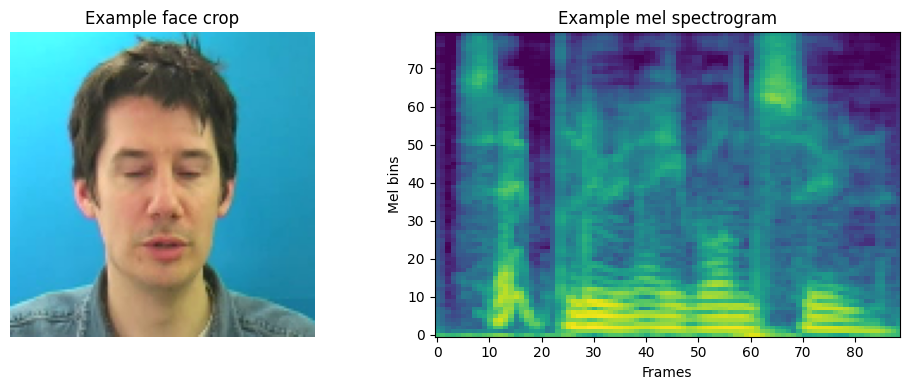

speaker_id                                                     s1
utterance_id                                               sbia1s
audio_path      /home/rja3097/CelebA/Tavishi/audio_25k/s1/sbia...
video_path       /home/rja3097/CelebA/Tavishi/video/s1/sbia1s.mpg
mel_path        /home/rja3097/CelebA/data/processed/grid_singl...
image_path      /home/rja3097/CelebA/data/processed/grid_singl...
Name: 0, dtype: object


In [214]:
sample_row = train_df.iloc[0]
sample_image = Image.open(sample_row["image_path"]).convert("RGB")
sample_mel = np.load(sample_row["mel_path"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_image)
axes[0].set_title("Example face crop")
axes[0].axis("off")

axes[1].imshow(sample_mel, aspect="auto", origin="lower")
axes[1].set_title("Example mel spectrogram")
axes[1].set_xlabel("Frames")
axes[1].set_ylabel("Mel bins")
plt.tight_layout()
plt.show()

print(sample_row)

## 6. Dataset Loader

In [215]:
class VoiceFaceDataset(Dataset):
    def __init__(self, csv_path: str, image_size: int = 64, max_frames: int = 128):
        self.df = pd.read_csv(csv_path)
        self.max_frames = max_frames
        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def _load_mel(self, path: str) -> torch.Tensor:
        mel = np.load(path)

        if mel.ndim != 2:
            raise ValueError(f"Expected mel spectrogram with 2 dims, got shape {mel.shape} from {path}")

        # Convert dB mel from [-80, 0] to [0, 1]
        mel = np.clip(mel, -80, 0)
        mel = (mel + 80) / 80.0

        mel = mel[:, : self.max_frames]

        if mel.shape[1] < self.max_frames:
            pad = np.zeros(
                (mel.shape[0], self.max_frames - mel.shape[1]),
                dtype=np.float32,
            )
            mel = np.concatenate([mel, pad], axis=1)

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        return mel

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image = self.image_transform(image)

        mel = self._load_mel(row["mel_path"])

        return {
            "mel": mel,
            "image": image,
            "speaker_id": row["speaker_id"],
            "utterance_id": row["utterance_id"],
        }

Train dataset size: 900
Val dataset size: 100
Mel shape: torch.Size([1, 80, 128])
Image shape: torch.Size([3, 128, 128])
Speaker: s1 | Utterance: sbia1s


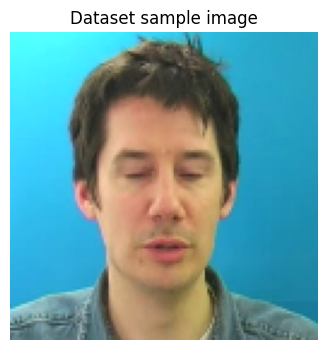

In [216]:
train_ds = VoiceFaceDataset(
    str(train_csv),
    image_size=cfg["data"]["image_size"],
    max_frames=cfg["data"]["max_frames"],
)

val_ds = VoiceFaceDataset(
    str(val_csv),
    image_size=cfg["data"]["image_size"],
    max_frames=cfg["data"]["max_frames"],
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:", len(val_ds))

sample = train_ds[0]
print("Mel shape:", sample["mel"].shape)
print("Image shape:", sample["image"].shape)
print("Speaker:", sample["speaker_id"], "| Utterance:", sample["utterance_id"])

plt.figure(figsize=(4, 4))
plt.imshow(sample["image"].permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Dataset sample image")
plt.show()

## 7. Model Architecture

In [217]:
class AudioEncoder(nn.Module):
    def __init__(self, embedding_dim: int = 128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(128, embedding_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.features(x).flatten(1)
        return self.proj(h)

In [218]:
class ImageEncoder(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.flatten_dim = 256 * 8 * 8
        self.mu = nn.Linear(self.flatten_dim, latent_dim)
        self.logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x: torch.Tensor):
        h = self.features(x).flatten(1)
        return self.mu(h), self.logvar(h)

In [219]:
class FaceDecoder(nn.Module):
    def __init__(self, latent_dim: int = 128, audio_embedding_dim: int = 128):
        super().__init__()
        in_dim = latent_dim + audio_embedding_dim
        self.fc = nn.Linear(in_dim, 256 * 8 * 8)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor, audio_embedding: torch.Tensor) -> torch.Tensor:
        x = torch.cat([z, audio_embedding], dim=1)
        h = self.fc(x).view(-1, 256, 8, 8)
        return self.net(h)

In [220]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim: int = 128, audio_embedding_dim: int = 128):
        super().__init__()
        self.latent_dim = latent_dim

        self.audio_encoder = AudioEncoder(embedding_dim=audio_embedding_dim)
        self.image_encoder = ImageEncoder(latent_dim=latent_dim)

        self.audio_mu = nn.Linear(audio_embedding_dim, latent_dim)
        self.audio_logvar = nn.Linear(audio_embedding_dim, latent_dim)

        self.decoder = FaceDecoder(
            latent_dim=latent_dim,
            audio_embedding_dim=audio_embedding_dim,
        )

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, mel: torch.Tensor, image: torch.Tensor):
        audio_embedding = self.audio_encoder(mel)

        image_mu, image_logvar = self.image_encoder(image)
        image_z = self.reparameterize(image_mu, image_logvar)

        audio_mu = self.audio_mu(audio_embedding)
        audio_logvar = self.audio_logvar(audio_embedding)

        recon = self.decoder(image_z, audio_embedding)

        return recon, image_mu, image_logvar, audio_mu, audio_logvar, audio_embedding

    def generate(self, mel: torch.Tensor) -> torch.Tensor:
        audio_embedding = self.audio_encoder(mel)

        audio_mu = self.audio_mu(audio_embedding)
        audio_logvar = self.audio_logvar(audio_embedding)

        z = self.reparameterize(audio_mu, audio_logvar)

        return self.decoder(z, audio_embedding)


def cvae_loss(
    recon: torch.Tensor,
    target: torch.Tensor,
    image_mu: torch.Tensor,
    image_logvar: torch.Tensor,
    audio_mu: torch.Tensor,
    beta: float = 0.0001,
    latent_weight: float = 0.1,
):
    recon_loss = F.l1_loss(recon, target, reduction="mean")

    edge_loss = F.l1_loss(
        recon[:, :, :, 1:] - recon[:, :, :, :-1],
        target[:, :, :, 1:] - target[:, :, :, :-1],
    )

    kl_loss = -0.5 * torch.mean(
        1 + image_logvar - image_mu.pow(2) - image_logvar.exp()
    )

    latent_match_loss = F.mse_loss(audio_mu, image_mu.detach())

    loss = recon_loss + 0.1 * edge_loss + beta * kl_loss + latent_weight * latent_match_loss

    metrics = {
        "recon_loss": recon_loss.item(),
        "edge_loss": edge_loss.item(),
        "kl_loss": kl_loss.item(),
        "latent_match_loss": latent_match_loss.item(),
    }

    return loss, metrics

## 8. Training Setup

In [221]:
train_loader = DataLoader(
    train_ds,
    batch_size=cfg["data"]["batch_size"],
    shuffle=True,
    num_workers=cfg["data"]["num_workers"],
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg["data"]["batch_size"],
    shuffle=False,
    num_workers=cfg["data"]["num_workers"],
)

model = ConditionalVAE(
    latent_dim=cfg["model"]["latent_dim"],
    audio_embedding_dim=cfg["model"]["audio_embedding_dim"],
).to(device)

optimizer = Adam(model.parameters(), lr=cfg["train"]["learning_rate"])

checkpoint_dir = PROJECT_ROOT / cfg["train"]["checkpoint_dir"]
sample_dir = PROJECT_ROOT / cfg["train"]["sample_dir"]
checkpoint_dir.mkdir(parents=True, exist_ok=True)
sample_dir.mkdir(parents=True, exist_ok=True)

print("Checkpoint dir:", checkpoint_dir)
print("Sample dir:", sample_dir)

Checkpoint dir: /home/rja3097/CelebA/data/checkpoints_single
Sample dir: /home/rja3097/CelebA/outputs/samples_single


In [222]:
def save_image_grid(images: torch.Tensor, save_path: str, nrow: int = 4) -> None:
    grid = make_grid(images.detach().cpu(), nrow=nrow, normalize=True, value_range=(0, 1))
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).numpy())
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()


@torch.no_grad()
def validate(model, loader, device, beta_kl):
    model.eval()
    total_loss = 0.0
    count = 0
    sample_batch = None

    for batch in loader:
        mel = batch["mel"].to(device)
        image = batch["image"].to(device)
        recon, image_mu, image_logvar, audio_mu, audio_logvar, _ = model(mel, image)
        loss, _ = cvae_loss(
            recon,
            image,
            image_mu,
            image_logvar,
            audio_mu,
            beta=beta_kl,
        )
        total_loss += loss.item()
        count += 1
        if sample_batch is None:
            sample_batch = recon[:8]

    return total_loss / max(count, 1), sample_batch

## 9. Train the Model

Set `RUN_TRAINING = True` only if you want to train from inside the notebook.  
Otherwise, you can skip this cell and load an existing checkpoint later.

In [223]:
RUN_TRAINING = True

history = {"val_loss": []}

if RUN_TRAINING:
    best_val_loss = float("inf")

    for epoch in range(cfg["train"]["epochs"]):
        model.train()
        progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{cfg['train']['epochs']}")

        for batch in progress:
            mel = batch["mel"].to(device)
            image = batch["image"].to(device)

            optimizer.zero_grad()
            recon, image_mu, image_logvar, audio_mu, audio_logvar, _ = model(mel, image)

            loss, metrics = cvae_loss(
                recon,
                image,
                image_mu,
                image_logvar,
                audio_mu,
                beta=cfg["train"]["beta_kl"],
            )
            loss.backward()
            optimizer.step()

            progress.set_postfix(
                loss=f"{loss.item():.4f}",
                recon=f"{metrics['recon_loss']:.4f}",
                edge=f"{metrics['edge_loss']:.4f}",
                latent=f"{metrics['latent_match_loss']:.4f}",
                kl=f"{metrics['kl_loss']:.4f}",
            )

        val_loss, sample_batch = validate(model, val_loader, device, cfg["train"]["beta_kl"])
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch + 1}: val_loss={val_loss:.4f}")

        if (epoch + 1) % cfg["train"]["sample_every_epoch"] == 0 and sample_batch is not None:
            save_image_grid(sample_batch, str(sample_dir / f"epoch_{epoch + 1:03d}.png"))

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "config": cfg,
        }

        latest_path = checkpoint_dir / "latest.pt"
        torch.save(checkpoint, latest_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = checkpoint_dir / "best.pt"
            torch.save(checkpoint, best_path)
            print(f"Saved best checkpoint to {best_path}")
else:
    print("Skipping training. Set RUN_TRAINING = True to train in the notebook.")

Epoch 1/500: 100%|██████████| 57/57 [00:01<00:00, 30.73it/s, edge=0.0767, kl=4.3094, latent=2.8359, loss=0.3862, recon=0.0945] 


Epoch 1: val_loss=0.2283
Saved best checkpoint to /home/rja3097/CelebA/data/checkpoints_single/best.pt


Epoch 2/500: 100%|██████████| 57/57 [00:00<00:00, 80.64it/s, edge=0.0447, kl=4.0436, latent=1.0639, loss=0.1639, recon=0.0527] 


Epoch 2: val_loss=0.1953
Saved best checkpoint to /home/rja3097/CelebA/data/checkpoints_single/best.pt


Epoch 3/500: 100%|██████████| 57/57 [00:00<00:00, 83.34it/s, edge=0.0369, kl=3.8582, latent=0.6108, loss=0.1089, recon=0.0438] 


...

Epoch 250: val_loss=0.1567


Epoch 251/500: 100%|██████████| 57/57 [00:00<00:00, 82.34it/s, edge=0.0185, kl=4.2119, latent=2.5952, loss=0.2810, recon=0.0192] 


Epoch 251: val_loss=0.1584


Epoch 252/500:  40%|████      | 23/57 [00:00<00:00, 66.01it/s, edge=0.0154, kl=3.4942, latent=0.9301, loss=0.1080, recon=0.0131]


KeyboardInterrupt: 

## 10. Load Best Checkpoint

In [224]:
checkpoint_path = checkpoint_dir / "best.pt"
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print("Loaded checkpoint:", checkpoint_path)
    print("Checkpoint epoch:", checkpoint.get("epoch"))
    print("Checkpoint val_loss:", checkpoint.get("val_loss"))
else:
    print("Checkpoint not found:", checkpoint_path)

Loaded checkpoint: /home/rja3097/CelebA/data/checkpoints_single/best.pt
Checkpoint epoch: 3
Checkpoint val_loss: 0.141109722001212


/tmp/ipykernel_198467/1518714469.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


## 11. Inference Utilities

In [225]:
def preprocess_audio_for_inference(audio_path: str, cfg):
    waveform, sr = load_audio(audio_path)
    mel = waveform_to_mel(
        waveform,
        sample_rate=sr,
        n_mels=cfg["data"]["n_mels"],
    )
    mel = np.clip(mel, -80, 0)
    mel = (mel + 80) / 80.0
    mel = mel[:, : cfg["data"]["max_frames"]]

    if mel.shape[1] < cfg["data"]["max_frames"]:
        pad = np.zeros(
            (mel.shape[0], cfg["data"]["max_frames"] - mel.shape[1]),
            dtype=mel.dtype,
        )
        mel = np.concatenate([mel, pad], axis=1)

    mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    return mel


def tensor_to_uint8(image_tensor: torch.Tensor):
    image = image_tensor.squeeze(0).detach().cpu().clamp(0, 1)
    image = image.permute(1, 2, 0).numpy()
    image = (image * 255).astype(np.uint8)
    return image


def sharpness_score(image_uint8: np.ndarray) -> float:
    gray = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def enhance_image(image_uint8: np.ndarray, upscale_factor: int = 2):
    image = Image.fromarray(image_uint8)
    image = image.resize(
        (image.width * upscale_factor, image.height * upscale_factor),
        Image.Resampling.BICUBIC,
    )
    image = ImageOps.autocontrast(image)
    image = image.filter(ImageFilter.UnsharpMask(radius=1.5, percent=130, threshold=3))
    return image

Test audio exists: True


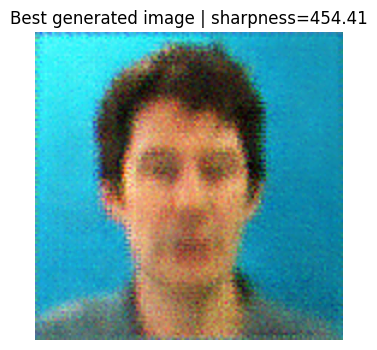

In [226]:
# Choose a test audio clip here
test_audio = RAW_GRID_ROOT / "audio_25k" / "s1" / "bbaf2n.wav"
print("Test audio exists:", test_audio.exists())

mel = preprocess_audio_for_inference(str(test_audio), cfg).to(device)

candidates = []
with torch.no_grad():
    for _ in range(8):
        generated = model.generate(mel)
        image_uint8 = tensor_to_uint8(generated)
        score = sharpness_score(image_uint8)
        candidates.append((score, image_uint8))

candidates.sort(key=lambda x: x[0], reverse=True)
best_score, best_image = candidates[0]
final_image = enhance_image(best_image, upscale_factor=2)

plt.figure(figsize=(4, 4))
plt.imshow(final_image)
plt.axis("off")
plt.title(f"Best generated image | sharpness={best_score:.2f}")
plt.show()

## 12. Generate Multiple Outputs for One Audio Clip

This demonstrates the generative nature of the CVAE by showing multiple samples for the same input audio.

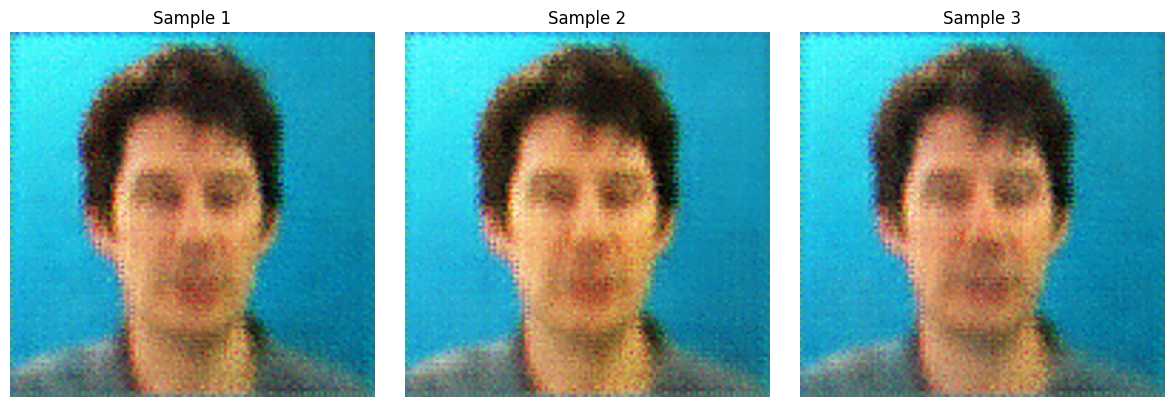

In [227]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
with torch.no_grad():
    for i in range(3):
        image = model.generate(mel)
        image_uint8 = tensor_to_uint8(image)
        image_up = enhance_image(image_uint8, upscale_factor=2)
        axes[i].imshow(image_up)
        axes[i].axis("off")
        axes[i].set_title(f"Sample {i+1}")
plt.tight_layout()
plt.show()

## 13. Batch Sample Generation

This creates a small validation batch of generated outputs and stores a CSV linking:
- target image
- generated image
- audio file

In [228]:
def save_pil_image(image: Image.Image, output_path: str):
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    image.save(output_path)


def generate_batch_samples(model, cfg, input_csv: Path, output_dir: Path, device, num_samples: int = 12):
    df = pd.read_csv(input_csv).head(num_samples)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_rows = []

    for _, row in df.iterrows():
        speaker_id = row["speaker_id"]
        utterance_id = row["utterance_id"]
        audio_path = row["audio_path"]

        mel = preprocess_audio_for_inference(audio_path, cfg).to(device)

        candidates = []
        with torch.no_grad():
            for _ in range(8):
                image = model.generate(mel)
                image_uint8 = tensor_to_uint8(image)
                score = sharpness_score(image_uint8)
                candidates.append((score, image_uint8))

        candidates.sort(key=lambda x: x[0], reverse=True)
        _, best_image = candidates[0]
        final_image = enhance_image(best_image, upscale_factor=2)

        output_path = output_dir / f"{speaker_id}_{utterance_id}_generated.png"
        save_pil_image(final_image, str(output_path))

        saved_rows.append(
            {
                "speaker_id": speaker_id,
                "utterance_id": utterance_id,
                "audio_path": audio_path,
                "target_image_path": row["image_path"],
                "generated_image_path": str(output_path),
            }
        )

    out_csv = output_dir / "generated_samples.csv"
    pd.DataFrame(saved_rows).to_csv(out_csv, index=False)
    return out_csv

In [229]:
generated_dir = PROJECT_ROOT / "outputs" / ("final_samples_single_nb" if EXPERIMENT_MODE == "single" else "final_samples_multi_nb")
generated_csv = generate_batch_samples(
    model=model,
    cfg=cfg,
    input_csv=val_csv,
    output_dir=generated_dir,
    device=device,
    num_samples=8,
)
print("Generated sample CSV:", generated_csv)
pd.read_csv(generated_csv).head()

Generated sample CSV: /home/rja3097/CelebA/outputs/final_samples_single_nb/generated_samples.csv


,speaker_id,utterance_id,audio_path,target_image_path,generated_image_path
0,s1,pwaj8p,/home/rja3097/CelebA/Tavishi/audio_25k/s1/pwaj...,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/outputs/final_samples_sin...
1,s1,bwig3a,/home/rja3097/CelebA/Tavishi/audio_25k/s1/bwig...,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/outputs/final_samples_sin...
2,s1,lrae3s,/home/rja3097/CelebA/Tavishi/audio_25k/s1/lrae...,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/outputs/final_samples_sin...
3,s1,lrbe7s,/home/rja3097/CelebA/Tavishi/audio_25k/s1/lrbe...,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/outputs/final_samples_sin...
4,s1,brwa4p,/home/rja3097/CelebA/Tavishi/audio_25k/s1/brwa...,/home/rja3097/CelebA/data/processed/grid_singl...,/home/rja3097/CelebA/outputs/final_samples_sin...


## 14. Target vs Generated Comparison Grid

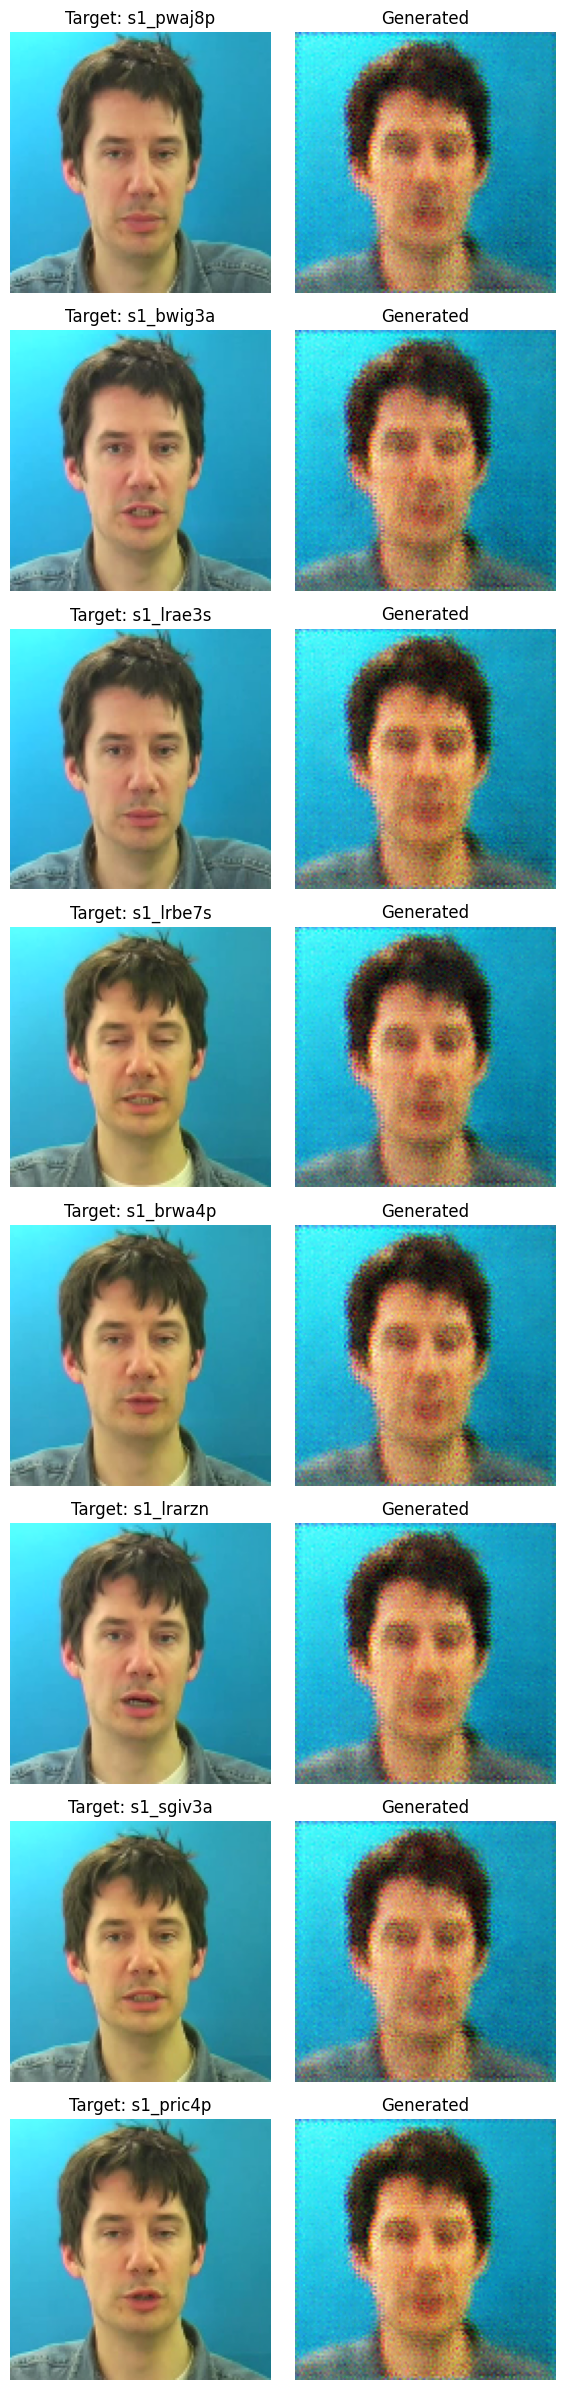

In [230]:
comparison_df = pd.read_csv(generated_csv)

rows = len(comparison_df)
fig, axes = plt.subplots(rows, 2, figsize=(6, 3 * rows))

if rows == 1:
    axes = [axes]

for i, (_, row) in enumerate(comparison_df.iterrows()):
    target = Image.open(row["target_image_path"]).convert("RGB")
    generated = Image.open(row["generated_image_path"]).convert("RGB")

    axes[i][0].imshow(target)
    axes[i][0].set_title(f"Target: {row['speaker_id']}_{row['utterance_id']}")
    axes[i][0].axis("off")

    axes[i][1].imshow(generated)
    axes[i][1].set_title("Generated")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

## 15. Single-Speaker vs Multi-Speaker Comparison

This section lets you compare the two training regimes.

- **Single-speaker** tends to produce more stable, recognizable faces.
- **Multi-speaker** tends to average identities and can look blurrier.

To compare them:
1. change `EXPERIMENT_MODE`
2. reload the config
3. load the corresponding checkpoint
4. rerun the inference cells

In [231]:
# Optional helper: display which checkpoint and config are currently active
print("Current experiment mode:", EXPERIMENT_MODE)
print("Current config:", CONFIG_PATH)
print("Current checkpoint path:", checkpoint_path)

Current experiment mode: single
Current config: /home/rja3097/CelebA/Tavishi/single_speaker.yaml
Current checkpoint path: /home/rja3097/CelebA/data/checkpoints_single/best.pt


## 16. Challenges and Improvements

Key challenges in the project included:
- the original VoxCeleb dataset path was not directly usable because it only exposed metadata/split files
- early CVAE outputs were very blurry
- multi-speaker training encouraged identity averaging
- Git/GitHub history initially tracked virtual environment files and had to be cleaned

Improvements added over time:
- moved to the GRID dataset
- increased image size from 64×64 to 128×128
- tightened face crops and then added face-detected cropping
- introduced single-speaker experiments
- switched from MSE to L1 reconstruction loss
- lowered learning rate for refinement
- added candidate sampling plus sharpness-based selection at inference time

## 17. Conclusion

This notebook demonstrates an end-to-end **voice-to-face generation** pipeline using a Conditional VAE.

The system:
- preprocesses paired GRID audio/video data
- extracts mel spectrograms and face crops
- trains a CVAE to map voice-conditioned latent structure to images
- generates face-like outputs from audio alone
- supports both single-speaker and multi-speaker experiments
- includes qualitative evaluation via batch generation and target-vs-generated comparison grids

The single-speaker model generally gives the clearest results, while the multi-speaker model is more challenging and tends to produce blurrier average faces. This behavior is consistent with expectations for a CVAE trained on limited data.

Future work could include:
- a face-to-caricature second stage
- latent interpolation analysis
- stronger decoders
- perceptual or adversarial losses for sharper images